# Credit Card ETL — Medallion Pipeline

Source: Kaggle `jinquan/cc-sample-data` → `cc_sample_transaction.json`

| Layer | What happens | Output |
|---|---|---|
| **Bronze** | Land the raw JSON untouched, add ingestion lineage | `data/bronze/transactions` |
| **Silver** | Flatten nested JSON, type, clean names, dedup, DQ gate, encrypt + hash PII | `data/silver/transactions` |
| **Gold** |  Aggregates for visualisation + one restricted table that decrypts PII | `data/gold/*` |

Run order is top to bottom. Each layer reads the layer above from disk, so a
layer can be re-run on its own.

### ✍️ Your notes — Project overview

_Prompts to answer: what is the business question? why medallion rather than one flat transform? what are you optimising for at each layer?_

<!-- write your explanation here -->

## 0. Setup

In [2]:
# All dependencies are pinned in requirements.txt 
#
# This notebook runs in a dedicated venv. Select the "Python (cc-fraud-etl)" kernel. To rebuild the environment from scratch:
#
#   python3 -m venv .venv
#   ./.venv/bin/python -m pip install -r requirements.txt
#   ./.venv/bin/python -m ipykernel install --user \
#       --name cc-fraud-etl --display-name "Python (cc-fraud-etl)"

# Confirm the kernel is the venv, not base:
import sys
print(sys.prefix)

/Users/lewisyuan/Documents/Github_RnD/de-zoomcamp-lewis/week-2/ny_taxi_postgres_data/.venv


In [3]:
import os
from pyspark.sql import SparkSession, functions as F, Window

# Where each medallion layer lands.
DATA_ROOT   = "data"
BRONZE_PATH = f"{DATA_ROOT}/bronze/transactions"
SILVER_PATH = f"{DATA_ROOT}/silver/transactions"
GOLD_PATH   = f"{DATA_ROOT}/gold"
DQ_RESULTS  = f"{DATA_ROOT}/_dq_results"
DQ_RULES    = "dq_rules.yaml"

In [4]:
spark = (SparkSession.builder.master("local[2]").appName("paynet-test")
         .config("spark.ui.enabled", "false")
         .config("spark.sql.shuffle.partitions", "4").getOrCreate())
spark.sparkContext.setLogLevel("ERROR")

# Target timezone is UTC+8 — Spark stores an instant and renders in session tz.
spark.conf.set("spark.sql.session.timeZone", "Asia/Kuala_Lumpur")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/09/19 22:21:13 WARN Utils: Your hostname, Lewiss-MacBook-Air.local, resolves to a loopback address: 127.0.0.1; using 192.168.0.100 instead (on interface en0)
26/09/19 22:21:13 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/19 22:21:14 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


---
# 1. Bronze — Landing layer


In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jinquan/cc-sample-data")

print("Path to dataset files:", path)
print(os.listdir(path))   # see what files came down

Path to dataset files: /Users/lewisyuan/.cache/kagglehub/datasets/jinquan/cc-sample-data/versions/1
['cc_sample_transaction.json']


In [6]:
bronze = spark.read.json(os.path.join(path, "cc_sample_transaction.json"))



+----------+------+-------------+-----------+----------------+--------+----------------+----------------------+------------------+-----------+-------------+--------------------+--------------------+---------------------+--------------------+
|Unnamed: 0|   amt|     category|     cc_bic|          cc_num|is_fraud|  merch_eff_time|merch_last_update_time|         merch_lat| merch_long|merch_zipcode|            merchant|     personal_detail|trans_date_trans_time|           trans_num|
+----------+------+-------------+-----------+----------------+--------+----------------+----------------------+------------------+-----------+-------------+--------------------+--------------------+---------------------+--------------------+
|         0|  4.97|     misc_net|CITIUS33CHI|2703186189652095|       0|1325376018798532|         1325376018666|         36.011293| -82.048315|        28705|fraud_Rippin, Kub...|{"person_name":"J...|  2019-01-01 00:00:18|0b242abb623afc578...|
|         1|107.23|  grocery_pos

In [7]:
bronze.printSchema()
bronze.show(5)

root
 |-- Unnamed: 0: string (nullable = true)
 |-- amt: string (nullable = true)
 |-- category: string (nullable = true)
 |-- cc_bic: string (nullable = true)
 |-- cc_num: string (nullable = true)
 |-- is_fraud: string (nullable = true)
 |-- merch_eff_time: string (nullable = true)
 |-- merch_last_update_time: string (nullable = true)
 |-- merch_lat: string (nullable = true)
 |-- merch_long: string (nullable = true)
 |-- merch_zipcode: string (nullable = true)
 |-- merchant: string (nullable = true)
 |-- personal_detail: string (nullable = true)
 |-- trans_date_trans_time: string (nullable = true)
 |-- trans_num: string (nullable = true)

+----------+------+-------------+-----------+----------------+--------+----------------+----------------------+------------------+-----------+-------------+--------------------+--------------------+---------------------+--------------------+
|Unnamed: 0|   amt|     category|     cc_bic|          cc_num|is_fraud|  merch_eff_time|merch_last_update_time

In [8]:
# Lineage columns — easy to trace files and ingestion time, in case there is file patching from source.
bronze = (bronze
    .withColumn("_ingested_at", F.current_timestamp())
    .withColumn("_source_file", F.input_file_name()))

bronze.write.mode("overwrite").parquet(BRONZE_PATH)

### Data checking before transformation

In [9]:
# Epoch columns arrive as strings with inconsistent digit widths. Suggested by AI.
bronze.select(
    F.length("merch_eff_time").alias("len_eff"),
    F.length("merch_last_update_time").alias("len_upd")
).distinct().show()

+-------+-------+
|len_eff|len_upd|
+-------+-------+
|     15|     13|
|     13|     12|
|     11|     13|
|     12|     12|
|     15|     11|
|     13|     13|
|     14|     12|
|     14|     11|
|     16|     13|
|     16|     11|
|     13|     11|
|     16|     12|
|     15|     12|
|     12|     13|
|     14|     13|
|     12|     11|
+-------+-------+



In [10]:
# Quick check personal_detail column before flattening and cleanup. 
bronze.select("personal_detail").show(10, truncate=False)

+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|personal_detail                                                                                                                                                                                                                                                                      |
+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|{"person_name":"Jennifer,Banks,eeeee","gender":"F","address":"{\"street\":\"561 Perry Cove\",\"city\":\"Moravian Falls\",\"state\":\"NC\",\"zip\":\"28654\"}","

---
# 2. Silver — Transformation layer

Denormalization , correct the data type, dedup and dq check

In [11]:
silver = spark.read.parquet(BRONZE_PATH)

### 2.1 Timestamps

Why using different timestamp based on different length 

In [12]:
silver = (silver
    .withColumn("merch_eff_time",
                F.timestamp_micros(F.col("merch_eff_time").cast("long")))
    .withColumn("merch_last_update_time",
                F.timestamp_millis(F.col("merch_last_update_time").cast("long")))
    .withColumn("trans_date_trans_time",
                F.to_utc_timestamp(F.to_timestamp("trans_date_trans_time"), "UTC")
    )
)

### 2.2 Flatten the nested JSON

In [13]:
pd_schema = ("person_name string, gender string, address string, "
             "lat string, long string, city_pop string, job string, dob string")
addr_schema = "street string, city string, state string, zip string"

silver = (silver
    .withColumn("pd", F.from_json("personal_detail", pd_schema))
    .withColumn("addr", F.from_json(F.col("pd.address"), addr_schema)))

In [ ]:
# To double check if there is null date inside the JSON
print("pd   unparsed:", silver.filter(F.col("pd").isNull() & F.col("personal_detail").isNotNull()).count())
print("addr unparsed:", silver.filter(F.col("addr").isNull() & F.col("pd.address").isNotNull()).count())

pd   unparsed: 0


addr unparsed: 0


In [15]:
silver = silver.select(
    # transaction-level columns already at top level
    "trans_num",
    "trans_date_trans_time",
    "cc_num",
    "cc_bic",
    "merchant",
    "category",
    F.col("amt").cast("decimal(12,2)").alias("amt"),
    F.col("is_fraud").cast("int").alias("is_fraud"),

    # merchant geo
    F.col("merch_lat").cast("double").alias("merch_lat"),
    F.col("merch_long").cast("double").alias("merch_long"),
    "merch_zipcode",

    # from personal_detail
    F.col("pd.person_name").alias("person_name"),
    F.col("pd.gender").alias("gender"),
    F.col("pd.job").alias("job"),
    F.to_date(F.col("pd.dob"), "yyyy-MM-dd").alias("dob"),
    F.col("pd.lat").cast("double").alias("cust_lat"),
    F.col("pd.long").cast("double").alias("cust_long"),
    F.col("pd.city_pop").cast("int").alias("city_pop"),

    # from the nested address
    F.col("addr.street").alias("street"),
    F.col("addr.city").alias("city"),
    F.col("addr.state").alias("state"),
    F.col("addr.zip").alias("zip"),

    # ADDED: carried from bronze — _ingested_at is the dedup tiebreaker in 2.4
    "_ingested_at",
    "_source_file",
)

### 2.3 Clean the corrupted names

In [16]:
JUNK_WORD = r"\b\w*(\w)\1{2,}\w*\b"        # any word with a 3+ identical-char run
NON_NAME  = r"[^A-Za-zÀ-ÿ\s'\-]"           # keep letters (incl. accents), space, ' and -

# CHANGED: was F.col("pd.person_name") — the `pd` struct no longer exists after
# the select in 2.2, so this reads the aliased flat column instead.
cleaned = F.regexp_replace(F.col("person_name"), JUNK_WORD, " ")
cleaned = F.regexp_replace(cleaned, NON_NAME, " ")      # , / @ | ; ! all become spaces

tokens = F.filter(
    F.split(F.trim(cleaned), r"\s+"),
    lambda c: F.length(c) > 0
)

silver = (silver
    .withColumn("name_tokens", tokens)
    .withColumn("first_name",
                F.when(F.size("name_tokens") > 0, F.element_at("name_tokens", 1)))
    .withColumn("last_name",
                F.when(F.size("name_tokens") > 1, F.element_at("name_tokens", -1))))

In [17]:
# Parse status keeps bad rows visible instead of silently nulling them.
silver = silver.withColumn("name_parse_status",
    F.when(F.col("person_name").isNull(), "null_source")
     .when(F.size("name_tokens") == 2, "ok")
     .when(F.size("name_tokens") == 0, "empty")
     .when(F.size("name_tokens") == 1, "single_token")
     .otherwise("multi_token"))

silver.groupBy("name_parse_status").count().show()

+-----------------+-------+
|name_parse_status|  count|
+-----------------+-------+
|               ok|1296675|
+-----------------+-------+



In [18]:
silver.select("person_name", "first_name", "last_name", "name_parse_status").show(10, truncate=False)

+------------------------+----------+---------+-----------------+
|person_name             |first_name|last_name|name_parse_status|
+------------------------+----------+---------+-----------------+
|Jennifer,Banks,eeeee    |Jennifer  |Banks    |ok               |
|Stephanie,Gill,eeeee    |Stephanie |Gill     |ok               |
|Edward@Sanchez          |Edward    |Sanchez  |ok               |
|Jeremy/White, !         |Jeremy    |White    |ok               |
|Tyler@Garcia            |Tyler     |Garcia   |ok               |
|Jennifer,Conner,eeeee   |Jennifer  |Conner   |ok               |
|Kelsey, , Richards NOOOO|Kelsey    |Richards |ok               |
|Steven, Williams        |Steven    |Williams |ok               |
|Heather, , Chase NOOOO  |Heather   |Chase    |ok               |
|Melissa@Aguilar         |Melissa   |Aguilar  |ok               |
+------------------------+----------+---------+-----------------+
only showing top 10 rows


### ✍️ Your notes — Name cleaning

_Prompts to answer: why regex rules instead of a name-parsing library? why must JUNK_WORD run before NON_NAME? why replace with a space rather than an empty string? why is `last_name` null on a single token instead of repeating `first_name`? what does the parse-status breakdown tell you?_

<!-- write your explanation here -->

### 2.4 Deduplicate

In [ ]:
# Surrogate key: md5 of the business key (trans_num + transaction instant).
#
# The best case is unique key provided by backend such as transaction ID. 
# If not, use a combination of fields that uniquely identify a row. 
# Here we use trans_num and trans_date_trans_time.

KEY_COLS = [
    F.coalesce(F.col("trans_num"), F.lit("__NULL__")),
    F.coalesce(F.unix_micros(F.col("trans_date_trans_time")).cast("string"), F.lit("__NULL__")),
]

silver = silver.withColumn("_scd_unique_id", F.md5(F.concat_ws("||", *KEY_COLS)))

silver.select("trans_num", "trans_date_trans_time", "_scd_unique_id").show(5, truncate=False)



+--------------------------------+---------------------+--------------------------------+
|trans_num                       |trans_date_trans_time|_scd_unique_id                  |
+--------------------------------+---------------------+--------------------------------+
|0b242abb623afc578575680df30655b9|2019-01-01 00:00:18  |f19057cf555faa6138f8791ff801379b|
|1f76529f8574734946361c461b024d99|2019-01-01 00:00:44  |2582ad8a1626ba7234d8c09bec3ad030|
|a1a22d70485983eac12b5b88dad1cf95|2019-01-01 00:00:51  |9a9a716a08b99520374fed7a129d8415|
|6b849c168bdad6f867558c3793159a81|2019-01-01 00:01:16  |89acafa4e0f4f1a99147833c3bd9e437|
|a41d7549acf90789359a9aa5346dcb46|2019-01-01 00:03:06  |b0d3d9f124cfe0b9b771e0378ba221a2|
+--------------------------------+---------------------+--------------------------------+
only showing top 5 rows


In [21]:
# Verify the key really is unique before locking it in as the dedup key.
print("rows:", silver.count())
print("distinct _scd_unique_id:", silver.select("_scd_unique_id").distinct().count())

silver.groupBy("_scd_unique_id").count().filter("count > 1").show()


rows: 1296675


distinct _scd_unique_id: 1296675


+--------------+-----+
|_scd_unique_id|count|
+--------------+-----+
+--------------+-----+



In [22]:
# Dedup on _scd_unique_id. Note the semantics: partitioning on the
# composite key keeps one row per (trans_num, timestamp) pair, whereas
# partitioning on trans_num alone would keep one row per transaction
# regardless of timestamp.
# row_number() over a window rather than dropDuplicates() — deterministic, and
# it chooses which record survives (latest ingest wins).
w = Window.partitionBy("_scd_unique_id").orderBy(F.col("_ingested_at").desc())

silver = (silver
    .withColumn("_rn", F.row_number().over(w))
    .filter("_rn = 1")
    .drop("_rn"))

print("rows after:", silver.count())

rows after: 1296675


### ✍️ Your notes — Dedup strategy

_Prompts to answer: why build an md5 surrogate key instead of deduping on `trans_num` directly? why `unix_micros()` rather than casting the timestamp to a string — what breaks if the session timezone changes? why `concat_ws` with a separator, and why coalesce nulls to a sentinel? is md5 appropriate here given it is cryptographically broken? why `row_number()` over a window rather than `dropDuplicates()`? did the source actually contain duplicates?_

<!-- write your explanation here -->

---
# 3. Data quality gate

Rules live in `dq_rules.yaml` (dbt `schema.yml` shape) so they can change
without touching pipeline code.

This runs **before** encryption — once `first_name` is ciphertext, "does this
look like a name" stops working.

In [23]:
import yaml


def run_dq(df, model_name, config_path=DQ_RULES):
    cfg = yaml.safe_load(open(config_path))[model_name]
    total = df.count()
    results = []

    for check in cfg["checks"]:
        col = check["column"]
        tests = check.get("tests", [])
        sev = check.get("severity", "warn")

        conds = []
        if "not_null" in tests:
            conds.append((f"{col}__not_null", F.col(col).isNotNull()))
        if "accepted_values" in check:
            conds.append((f"{col}__accepted_values", F.col(col).isin(check["accepted_values"])))
        if "expression" in check:
            conds.append((f"{col}__expression", F.expr(check["expression"])))

        for name, cond in conds:
            # Three-valued logic: a null makes `cond` null, not false, so it
            # slips past a plain ~cond. Count it as a failure explicitly.
            failed = df.filter(~cond | cond.isNull()).count()
            results.append((name, sev, failed, round(100 * failed / total, 3)))

        if "unique" in tests:
            dupes = df.groupBy(col).count().filter("count > 1").count()
            results.append((f"{col}__unique", sev, dupes, round(100 * dupes / total, 3)))

    report = spark.createDataFrame(
        results, "check string, severity string, failed_rows long, failed_pct double")

    errors = [r for r in results if r[1] == "error" and r[2] > 0]
    if errors:
        report.show(50, False)
        raise ValueError(f"DQ gate failed on {len(errors)} error-severity checks")

    return report

In [24]:
dq_report = run_dq(silver, "silver_transactions")
dq_report.show(50, truncate=False)

+----------------------------------+--------+-----------+----------+
|check                             |severity|failed_rows|failed_pct|
+----------------------------------+--------+-----------+----------+
|_scd_unique_id__not_null          |error   |0          |0.0       |
|_scd_unique_id__unique            |error   |0          |0.0       |
|trans_num__not_null               |error   |0          |0.0       |
|trans_num__unique                 |error   |0          |0.0       |
|amt__not_null                     |error   |0          |0.0       |
|amt__expression                   |error   |0          |0.0       |
|gender__accepted_values           |warn    |0          |0.0       |
|is_fraud__accepted_values         |error   |0          |0.0       |
|cust_lat__expression              |warn    |0          |0.0       |
|cust_long__expression             |warn    |0          |0.0       |
|state__expression                 |warn    |0          |0.0       |
|zip__expression                  

In [25]:
# Persist every run so a check drifting from 0.1% to 4% is visible, not just pass/fail.
(dq_report
 .withColumn("model", F.lit("silver_transactions"))
 .withColumn("run_ts", F.current_timestamp())
 .write.mode("append").parquet(DQ_RESULTS))

### ✍️ Your notes — Data quality framework

_Prompts to answer: why external YAML instead of assertions in code? which checks are `error` vs `warn`, and why? what did the failures actually show about the dataset? why must the gate run before encryption? what is the risk of `F.expr()` executing arbitrary SQL?_

<!-- write your explanation here -->

---
# 4. PII — encrypt for recovery, hash for joins

Spark has no equivalent to a Snowflake masking policy — no role-based
application at read time. So the pattern inverts: **transform at write**,
enforce with **storage permissions**.

Two outputs, two jobs:

| Output | Function | Purpose | Reversible |
|---|---|---|---|
| `*_hash` | `sha2` + salt | join / group / merge keys | no |
| `*_enc` | `aes_encrypt` ECB | retrieval by the one authorised gold table | yes |

ECB is deterministic (so joinable) but **leaks equality** — an attacker can
count transactions per card without decrypting. GCM is secure but uses a random
IV per row, so identical inputs differ every run and it cannot be a join key.

### What is protected, and what is not

| Column | Treatment |
|---|---|
| `cc_num` | hashed **and** encrypted |
| `cc_bic` | hashed **and** encrypted |
| `first_name`, `last_name` | encrypted |
| `street`, `dob` | **plaintext** — see the note in 4.3 |
| `gender`, `job`, `city`, `state`, `zip` | plaintext |


In [ ]:
# Generate the salt and key ONCE, then keep them. Regenerating the salt changes
# every hash and breaks joins to already-written data.
# import secrets
# print("PII_SALT   =", secrets.token_hex(32))
# print("PII_AES_KEY=", secrets.token_hex(16))   # 32 chars = 32 bytes, a valid AES key

In [26]:
from dotenv import load_dotenv

load_dotenv()
SALT    = os.environ["PII_SALT"]        # KeyError on missing, deliberately
AES_KEY = os.environ["PII_AES_KEY"]

### 4.1 Encrypt (reversible) — must run before hashing overwrites the plaintext

In [27]:
def encrypt_pii(col_name, key=AES_KEY):
    return F.when(
        F.col(col_name).isNotNull(),
        F.aes_encrypt(F.col(col_name).cast("string"), F.lit(key), F.lit("ECB"))
    )


# Encrypted set = card identifiers + name. street/dob stay plaintext by design —
# see the note in 4.3 about what that means for where silver is allowed to live.
silver = (silver
    .withColumn("cc_num_enc",     encrypt_pii("cc_num"))
    .withColumn("cc_bic_enc",     encrypt_pii("cc_bic"))
    .withColumn("first_name_enc", encrypt_pii("first_name"))
    .withColumn("last_name_enc",  encrypt_pii("last_name")))


### 4.2 Hash (irreversible) — join and grouping keys

In [28]:
def hash_pii(col_name, salt=SALT):
    return F.when(
        F.col(col_name).isNotNull(),
        F.sha2(F.concat(F.lit(salt), F.col(col_name).cast("string")), 256)
    )

silver = (silver
    .withColumn("cc_num",     hash_pii("cc_num"))
    .withColumn("cc_bic", hash_pii("cc_bic")))

### 4.3 Drop the plaintext and write silver

In [29]:
# Encrypting the extracted columns while leaving the plaintext behind masks
# nothing — this is the easiest leak to ship by accident.
#
# NOTE: street and dob are deliberately NOT encrypted, so they survive here in
# plaintext. That is a conscious trade for analytics usability, but it means
# silver itself is a directly-identifying dataset: street + city + state + zip
# is a mailing address, and dob + zip + gender is the classic re-identification
# triple. Silver therefore cannot sit in a general-access prefix just because
# the card number is encrypted.
silver = silver.drop(
    "person_name", "name_tokens", "first_name", "last_name",
    "_source_file",
)

silver.printSchema()


root
 |-- trans_num: string (nullable = true)
 |-- trans_date_trans_time: timestamp (nullable = true)
 |-- cc_num: string (nullable = true)
 |-- cc_bic: string (nullable = true)
 |-- merchant: string (nullable = true)
 |-- category: string (nullable = true)
 |-- amt: decimal(12,2) (nullable = true)
 |-- is_fraud: integer (nullable = true)
 |-- merch_lat: double (nullable = true)
 |-- merch_long: double (nullable = true)
 |-- merch_zipcode: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- job: string (nullable = true)
 |-- dob: date (nullable = true)
 |-- cust_lat: double (nullable = true)
 |-- cust_long: double (nullable = true)
 |-- city_pop: integer (nullable = true)
 |-- street: string (nullable = true)
 |-- city: string (nullable = true)
 |-- state: string (nullable = true)
 |-- zip: string (nullable = true)
 |-- _ingested_at: timestamp (nullable = true)
 |-- name_parse_status: string (nullable = false)
 |-- _scd_unique_id: string (nullable = false)
 |-- cc_num_e

In [30]:
silver.write.mode("overwrite").parquet(SILVER_PATH)
# TODO: consider .partitionBy("trans_year", "trans_month") once those columns are derived.

### ✍️ Your notes — PII strategy

_Prompts to answer: why encrypt *and* hash rather than picking one? why ECB and what does it leak? why must the raw `person_name` blob be dropped? where does the *actual* enforcement live (hint: it is not the transform)? what breaks if the salt is rotated in place?_

<!-- write your explanation here -->

---
# 5. Gold — analysis tables

Four tables, split across **two access tiers**. The tier, not the transform, is
what actually protects anything.

| Table | Tier | Grain |
|---|---|---|
| `gold_decrypt_customer_master` | **restricted** — needs the AES key | one row per customer |
| `gold_analysis_customer_demographic` | analytics | one row per demographic segment |
| `gold_analysis_fraud` | analytics | one row per fraudulent transaction |
| `gold_analysis_merchant_sales` | analytics | one row per merchant per month |

Only the first needs `AES_KEY`. The other three read hashed/plaintext silver and
never touch the key — which is what lets them live in the general analytics
prefix.

In [31]:
silver_tbl = spark.read.parquet(SILVER_PATH)

# Age is computed against a fixed reference date, not current_date(), so the
# tables are reproducible — otherwise every re-run shifts the age bands.
ANALYSIS_DATE = F.lit("2020-07-01").cast("date")

# Customer grain = the cc_num hash, latest transaction wins. Defined here rather
# than inside 5.1 so the analytics tables can use it without the restricted cell.
w_cust = Window.partitionBy("cc_num").orderBy(F.col("trans_date_trans_time").desc())

print("silver rows:", silver_tbl.count())


silver rows: 1296675


## 5.1 `gold_decrypt_customer_master` — RESTRICTED

The only table that holds the AES key. Runs under the privileged service
account; lands in its own prefix with a narrow IAM policy.

Customer grain is the `cc_num` **hash**: deterministic, so it groups correctly
without ever decrypting. This is exactly why the hash exists alongside the
ciphertext. Attributes are taken from the customer's *most recent* transaction,
so an address change resolves to the latest known value.

In [32]:
def decrypt_pii(col_name, key=AES_KEY):
    # aes_decrypt returns binary, hence the cast. A wrong key throws rather than
    # returning garbage, so a botched key rotation fails loudly.
    return F.aes_decrypt(F.col(col_name), F.lit(key), F.lit("ECB")).cast("string")


# One row per customer: latest transaction wins (w_cust defined above).
gold_decrypt_customer_master = (silver_tbl
    .withColumn("_rn", F.row_number().over(w_cust))
    .filter("_rn = 1")
    .select(
        F.col("cc_num").alias("cc_num_hash"),          # stable customer key
        decrypt_pii("cc_num_enc").alias("cc_num"),
        decrypt_pii("cc_bic_enc").alias("cc_bic"),
        decrypt_pii("first_name_enc").alias("first_name"),
        decrypt_pii("last_name_enc").alias("last_name"),
        "gender", "job", "dob",
        "street", "city", "state", "zip",
        "cust_lat", "cust_long", "city_pop",
        F.col("trans_date_trans_time").alias("last_seen_at"),
    ))

print("customers:", gold_decrypt_customer_master.count())
gold_decrypt_customer_master.show(5, truncate=False)

customers: 983


+----------------------------------------------------------------+-------------------+-----------+----------+---------+------+-------------------------------+----------+-------------------------------+-----------+-----+-----+------------------+---------+--------+-------------------+
|cc_num_hash                                                     |cc_num             |cc_bic     |first_name|last_name|gender|job                            |dob       |street                         |city       |state|zip  |cust_lat          |cust_long|city_pop|last_seen_at       |
+----------------------------------------------------------------+-------------------+-----------+----------+---------+------+-------------------------------+----------+-------------------------------+-----------+-----+-----+------------------+---------+--------+-------------------+
|000089d0337d3bbc60438826040e025f336f899f55e4abf74c5fb54a72060178|4911818930706644725|DEUTUS33TRF|Jeremy    |Chavez   |M     |Landscape architect   

In [ ]:
# TODO: write to a SEPARATE restricted prefix, never alongside analytics gold.
# gold_decrypt_customer_master.write.mode("overwrite").parquet(f"{GOLD_PATH}/restricted/customer_master")

### ✍️ Your notes — Restricted customer master

_Prompts to answer: why is the customer grain the cc_num *hash* rather than the decrypted number? who is allowed to run this cell, and what stops an analyst reading silver directly instead? why take the latest transaction's attributes rather than the first?_

<!-- write your explanation here -->

## 5.2 `gold_analysis_customer_demographic`

Aggregated customer segments — no key, no ciphertext, no names.

Built from the **customer** grain, not the transaction grain. Aggregating
transactions directly would weight each customer by how often they shop, so a
heavy spender would count as many customers.

In [33]:
# Customer-level base (no decryption — hash key + plaintext attributes only).
cust_base = (silver_tbl
    .withColumn("_rn", F.row_number().over(w_cust))
    .filter("_rn = 1")
    .select(F.col("cc_num").alias("cc_num_hash"),
            "gender", "job", "dob", "city", "state", "zip", "city_pop"))

age = F.floor(F.months_between(ANALYSIS_DATE, F.col("dob")) / 12)

cust_base = cust_base.withColumn("age_band",
    F.when(age < 25, "18-24")
     .when(age < 35, "25-34")
     .when(age < 45, "35-44")
     .when(age < 55, "45-54")
     .when(age < 65, "55-64")
     .when(age >= 65, "65+")
     .otherwise("unknown"))

In [37]:
# Spend / fraud behaviour per customer, joined onto the demographic attributes.
cust_activity = (silver_tbl.groupBy(F.col("cc_num").alias("cc_num_hash"))
    .agg(F.count("*").alias("txn_count"),
         F.sum("amt").alias("total_amt"),
         F.sum("is_fraud").alias("fraud_txn_count")))

gold_analysis_customer_demographic = (cust_base.join(cust_activity, "cc_num_hash", "left")
    .groupBy("gender", "age_band", "state", "job")
    .agg(F.count("*").alias("customer_count"),
         F.sum("txn_count").alias("txn_count"),
         F.round(F.sum("total_amt"), 2).alias("total_amt"),
         F.round(F.avg("total_amt"), 2).alias("avg_amt_per_customer"),
         F.sum("fraud_txn_count").alias("fraud_txn_count"))
    .withColumn("fraud_rate_pct",
                F.round(100 * F.col("fraud_txn_count") / F.col("txn_count"), 3))
    # k-anonymity flag: a segment matching very few customers can re-identify
    # them, especially since job + state + age_band is close to unique.
    .withColumn("small_segment", F.col("customer_count") < 5)
    .orderBy(F.desc("customer_count")))

gold_analysis_customer_demographic.show(10, truncate=False)

+------+--------+-----+----------------------------------+--------------+---------+---------+--------------------+---------------+--------------+-------------+
|gender|age_band|state|job                               |customer_count|txn_count|total_amt|avg_amt_per_customer|fraud_txn_count|fraud_rate_pct|small_segment|
+------+--------+-----+----------------------------------+--------------+---------+---------+--------------------+---------------+--------------+-------------+
|F     |65+     |PA   |Mining engineer                   |2             |4091     |260519.63|130259.82           |14             |0.342         |true         |
|M     |35-44   |TX   |Petroleum engineer                |2             |2548     |244324.38|122162.19           |14             |0.549         |true         |
|M     |55-64   |WI   |Public relations officer          |1             |518      |31084.88 |31084.88            |5              |0.965         |true         |
|F     |45-54   |WA   |Public house mana

In [38]:
# How much of this table is actually safe to publish?
tot = gold_analysis_customer_demographic.count()
small = gold_analysis_customer_demographic.filter("small_segment").count()
print(f"segments: {tot} | segments with <5 customers: {small} ({round(100*small/tot,1)}%)")

# gold_analysis_customer_demographic.write.mode("overwrite").parquet(f"{GOLD_PATH}/analysis_customer_demographic")

segments: 981 | segments with <5 customers: 981 (100.0%)


### ✍️ Your notes — Customer demographics

_Prompts to answer: why aggregate at customer grain rather than transaction grain — what would skew if you did not? what does the small_segment count tell you about publishing this table, given job + state + age_band is near-unique per person? would you drop job, coarsen it, or suppress small segments?_

<!-- write your explanation here -->

## 5.3 `gold_analysis_fraud`

Fraudulent transactions only, as specified. `is_fraud` is an **int 0/1**, not a
boolean, so the filter is `is_fraud = 1` — a deliberate typing choice from
silver, since a bool cast would have hidden any unexpected third value.

`cc_num` here is the **hash**. Fraud analysis needs to group by card, not read
it, so this table stays in the analytics tier.

Customer-to-merchant distance is included: it is the standard engineered
feature for this dataset, and a card transacting far from its home location is
the classic signal.

In [39]:
# Haversine distance, customer home -> merchant, in km.
R_KM = 6371.0
dlat = F.radians(F.col("merch_lat") - F.col("cust_lat"))
dlon = F.radians(F.col("merch_long") - F.col("cust_long"))
hav = (F.sin(dlat / 2) ** 2
       + F.cos(F.radians(F.col("cust_lat"))) * F.cos(F.radians(F.col("merch_lat")))
       * F.sin(dlon / 2) ** 2)
distance_km = F.round(2 * R_KM * F.asin(F.sqrt(hav)), 2)

gold_analysis_fraud = (silver_tbl
    .filter(F.col("is_fraud") == 1)
    .select(
        "trans_num",
        "trans_date_trans_time",
        F.col("cc_num").alias("cc_num_hash"),
        "merchant",
        "category",
        "amt",
        "city", "state", "zip",                 # cardholder area
        "merch_zipcode",                        # merchant area
        distance_km.alias("cust_merch_distance_km"),
        F.hour("trans_date_trans_time").alias("trans_hour"),
    ))

print("fraudulent transactions:", gold_analysis_fraud.count())
gold_analysis_fraud.show(10, truncate=False)

# gold_analysis_fraud.write.mode("overwrite").parquet(f"{GOLD_PATH}/analysis_fraud")

fraudulent transactions: 7506
+--------------------------------+---------------------+----------------------------------------------------------------+----------------------------------+-------------+-------+------------+-----+-----+-------------+----------------------+----------+
|trans_num                       |trans_date_trans_time|cc_num_hash                                                     |merchant                          |category     |amt    |city        |state|zip  |merch_zipcode|cust_merch_distance_km|trans_hour|
+--------------------------------+---------------------+----------------------------------------------------------------+----------------------------------+-------------+-------+------------+-----+-----+-------------+----------------------+----------+
|3abff75e07e041f7c4b5188c0146edcf|2019-09-11 01:23:21  |0dec421b9f40486e56373d9031895234451fdc77d150e1690420a3fbd001cd43|fraud_Heidenreich PLC             |grocery_pos  |312.41 |Egan        |LA   |70531|NULL       

### 5.3b Comparative profile — the table that actually answers "is there a relationship?"

A fraud-only table gives you the numerator but not the denominator. "Most fraud
happens in `grocery_pos`" may simply mean most *transactions* are `grocery_pos`.
To find a relationship you have to compare the fraud population against the
non-fraud population on the same dimension.

In [40]:
def fraud_profile(df, *dims):
    """Fraud rate by dimension — fraud count over total, not fraud count alone."""
    return (df.groupBy(*dims)
        .agg(F.count("*").alias("txn_count"),
             F.sum("is_fraud").alias("fraud_count"),
             F.round(F.avg("amt"), 2).alias("avg_amt"),
             F.round(F.avg(F.when(F.col("is_fraud") == 1, F.col("amt"))), 2).alias("avg_fraud_amt"))
        .withColumn("fraud_rate_pct",
                    F.round(100 * F.col("fraud_count") / F.col("txn_count"), 3))
        .orderBy(F.desc("fraud_rate_pct")))


enriched = silver_tbl.withColumn("cust_merch_distance_km", distance_km)

print("--- by category ---")
fraud_profile(enriched, "category").show(15, truncate=False)

print("--- by hour of day ---")
fraud_profile(enriched, F.hour("trans_date_trans_time").alias("trans_hour")) \
    .orderBy("trans_hour").show(24, truncate=False)

--- by category ---
+--------------+---------+-----------+-------+-------------+--------------+
|category      |txn_count|fraud_count|avg_amt|avg_fraud_amt|fraud_rate_pct|
+--------------+---------+-----------+-------+-------------+--------------+
|shopping_net  |97543    |1713       |88.42  |999.25       |1.756         |
|misc_net      |63287    |915        |80.87  |797.01       |1.446         |
|grocery_pos   |123638   |1743       |116.96 |311.99       |1.41          |
|shopping_pos  |116672   |843        |79.78  |876.92       |0.723         |
|gas_transport |131659   |618        |63.43  |12.29        |0.469         |
|misc_pos      |79655    |250        |62.89  |218.28       |0.314         |
|grocery_net   |45452    |134        |53.67  |12.16        |0.295         |
|travel        |40507    |116        |111.50 |9.06         |0.286         |
|entertainment |94014    |233        |64.21  |503.54       |0.248         |
|personal_care |90758    |220        |47.97  |26.17        |0.242   

In [43]:
# Amount and distance bands — does either separate fraud from normal traffic?
banded = (enriched
    .withColumn("amt_band",
        F.when(F.col("amt") < 10, "a: <10")
         .when(F.col("amt") < 50, "b: 10-50")
         .when(F.col("amt") < 100, "c: 50-100")
         .when(F.col("amt") < 500, "d: 100-500")
         .otherwise("e: 500+"))
    .withColumn("distance_band",
        F.when(F.col("cust_merch_distance_km") < 10, "a: <10km")
         .when(F.col("cust_merch_distance_km") < 50, "b: 10-50km")
         .when(F.col("cust_merch_distance_km") < 100, "c: 50-100km")
         .otherwise("d: 100km+")))

print("--- by amount band ---")
fraud_profile(banded, "amt_band").orderBy("amt_band").show(truncate=False)

print("--- by distance band ---")
fraud_profile(banded, "distance_band").orderBy("distance_band").show(truncate=False)

--- by amount band ---
+----------+---------+-----------+-------+-------------+--------------+
|amt_band  |txn_count|fraud_count|avg_amt|avg_fraud_amt|fraud_rate_pct|
+----------+---------+-----------+-------+-------------+--------------+
|a: <10    |335718   |525        |5.26   |8.09         |0.156         |
|b: 10-50  |336496   |1082       |30.09  |18.51        |0.322         |
|c: 50-100 |389514   |45         |71.67  |57.15        |0.012         |
|d: 100-500|219316   |2206       |165.71 |301.74       |1.006         |
|e: 500+   |15631    |3648       |964.26 |903.40       |23.338        |
+----------+---------+-----------+-------+-------------+--------------+

--- by distance band ---
+-------------+---------+-----------+-------+-------------+--------------+
|distance_band|txn_count|fraud_count|avg_amt|avg_fraud_amt|fraud_rate_pct|
+-------------+---------+-----------+-------+-------------+--------------+
|a: <10km     |10552    |53         |72.53  |566.87       |0.502         |
|b:

### ✍️ Your notes — Fraud analysis

_Prompts to answer: why does a fraud-only table struggle to show a *relationship*, and what does 5.3b add? which dimension separates fraud most strongly — amount, hour, distance or category? why is the hashed cc_num sufficient here? is customer-to-merchant distance actually predictive in this data, and does that match what you expected?_

<!-- write your explanation here -->

## 5.4 `gold_analysis_merchant_sales`

Merchant × month, for marketing targeting. Includes merchant location so the
output can be mapped, and a fraud rate so a high-revenue-but-high-fraud merchant
is not targeted blindly.

Month comes from `trans_date_trans_time`, **not** the epoch columns — those
resolve to 2012 while the transaction timestamps say 2019, and the two do not
cross-validate (see Open Items).

In [41]:
gold_analysis_merchant_sales = (silver_tbl
    .withColumn("trans_month", F.date_format("trans_date_trans_time", "yyyy-MM"))
    .groupBy("merchant", "trans_month")
    .agg(F.round(F.sum("amt"), 2).alias("total_amt"),
         F.count("*").alias("txn_count"),
         F.countDistinct("cc_num").alias("unique_customers"),
         F.round(F.avg("amt"), 2).alias("avg_ticket"),
         F.sum("is_fraud").alias("fraud_count"),
         # merchant location is fixed per merchant; first() is safe at this grain
         F.first("merch_lat", ignorenulls=True).alias("merch_lat"),
         F.first("merch_long", ignorenulls=True).alias("merch_long"),
         F.first("merch_zipcode", ignorenulls=True).alias("merch_zipcode"))
    .withColumn("fraud_rate_pct",
                F.round(100 * F.col("fraud_count") / F.col("txn_count"), 3))
    .withColumn("amt_per_customer",
                F.round(F.col("total_amt") / F.col("unique_customers"), 2))
    .orderBy(F.desc("total_amt")))

gold_analysis_merchant_sales.show(10, truncate=False)

# gold_analysis_merchant_sales.write.mode("overwrite").parquet(f"{GOLD_PATH}/analysis_merchant_sales")

+-----------------------------------+-----------+---------+---------+----------------+----------+-----------+---------+------------------+-------------+--------------+----------------+
|merchant                           |trans_month|total_amt|txn_count|unique_customers|avg_ticket|fraud_count|merch_lat|merch_long        |merch_zipcode|fraud_rate_pct|amt_per_customer|
+-----------------------------------+-----------+---------+---------+----------------+----------+-----------+---------+------------------+-------------+--------------+----------------+
|fraud_Kilback LLC                  |2019-12    |46645.70 |516      |384             |90.40     |4          |42.79658 |-78.487462        |14037        |0.775         |121.47          |
|fraud_Heidenreich PLC              |2019-12    |35686.63 |301      |242             |118.56    |1          |38.874406|-86.13282         |47260        |0.332         |147.47          |
|fraud_Bailey-Morar                 |2019-12    |35227.60 |310      |259   

### ✍️ Your notes — Merchant sales

_Prompts to answer: why month-over-month rather than a single total? why include fraud_rate_pct in a *marketing* table? why is `first()` acceptable for merchant location but would be wrong for customer address? why use trans_date_trans_time rather than merch_eff_time for the month?_

<!-- write your explanation here -->

## 5.5 Visualisation

Gold tables are small enough to collect to the driver with `toPandas()`.

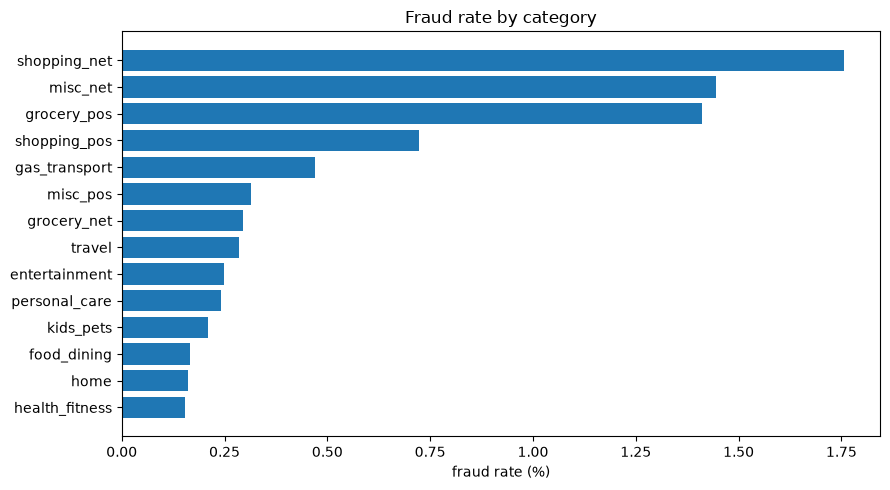

In [42]:
import matplotlib.pyplot as plt

# TODO: your charts. One worked example to start from — fraud rate by category.
pdf = fraud_profile(enriched, "category").toPandas()

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(pdf["category"], pdf["fraud_rate_pct"])
ax.invert_yaxis()
ax.set_xlabel("fraud rate (%)")
ax.set_title("Fraud rate by category")
fig.tight_layout()
plt.show()

In [ ]:
# TODO: second chart — e.g. merchant sales trend by month, or fraud rate by hour.

### ✍️ Your notes — Visualisation

_Prompts to answer: what does each chart show and who is the audience? what did the chart reveal that the table did not? is a fraud *rate* or a fraud *count* the honest thing to plot here?_

<!-- write your explanation here -->

---
## Open items

- [ ] **Epoch digit-length anomaly** — 11/12/14/15-digit values sit between the
      valid widths (10 sec / 13 ms / 16 µs). Decide whether they are recoverable
      or quarantine-only. Current code assumes µs and ms uniformly.
- [ ] The epoch columns resolve to **2012** while `trans_date_trans_time` says
      **2019** — pick one as source of truth, they do not cross-validate.
- [ ] Scan for name delimiters not yet seen.
- [ ] Decide which columns beyond `cc_num` / names / `street` / `dob` need
      encrypting vs hashing vs leaving plain.
- [ ] Define the gold tables and the visualisation (§5).
- [ ] Wire the DQ gate into orchestration so error-severity breaches fail the run.